In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.linear_model import LinearRegression

In [2]:
# ---------------------------------------
# 1. Load Data
# ---------------------------------------
df = pd.read_csv(r"C:\Users\Kiruthiha\Documents\Kiruthiha_Docs\Virtual_Internships\JP_Morgan_Case_Quantitative_Researcher\Nat_Gas.csv")
df.head()

,Dates,Prices
0,10/31/20,10.1
1,11/30/20,10.3
2,12/31/20,11.0
3,1/31/21,10.9
4,2/28/21,10.9


In [3]:
# Convert Dates column into datetime format
# The dates in the CSV are in MM/DD/YY format
# Example: 10/31/20
df["Dates"] = pd.to_datetime(df["Dates"], format="%m/%d/%y")
df = df.sort_values("Dates")

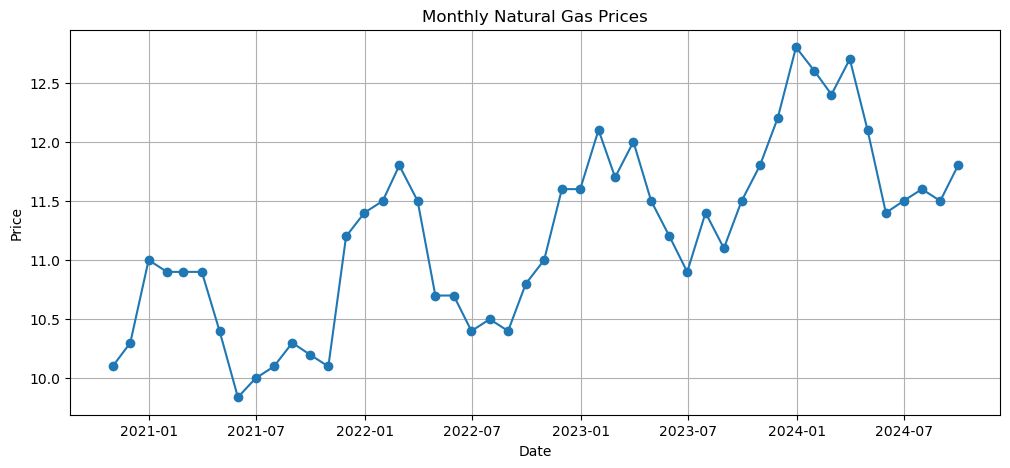

In [4]:
# ---------------------------------------
# 2. Visualize Historical Prices
# ---------------------------------------
plt.figure(figsize=(12,5))
plt.plot(df["Dates"], df["Prices"], marker='o')
plt.title("Monthly Natural Gas Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [5]:
# ---------------------------------------
# 3. Feature Engineering
# ---------------------------------------

# Calculate the number of days since the first observation in the dataset
df["Days"] = (df["Dates"] - df["Dates"].min()).dt.days

# Create Seasonal Features
df["sin"] = np.sin(2*np.pi*df["Days"]/365.25)
df["cos"] = np.cos(2*np.pi*df["Days"]/365.25)

# Select input features
X = df[["Days","sin","cos"]]

# Target variable
y = df["Prices"]

In [6]:
# ---------------------------------------
# 4. Train the Linear Regression model
# ---------------------------------------
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
# ---------------------------------------
# 5. Create interpolation function
# ---------------------------------------
interp = interp1d(
    df["Days"],
    df["Prices"],
    kind="linear",
    fill_value="extrapolate"
)

In [8]:
# ---------------------------------------
# 6. Create price estimation function
# ---------------------------------------

def estimate_price(input_date):
    """
    Estimate natural gas price for any date.

    Parameters:
        input_date (str): Format 'YYYY-MM-DD'

    Returns:
        Estimated price
    """

    # Convert the input date into datetime format
    date = pd.to_datetime(input_date)

    days = (date - df["Dates"].min()).days

    # -----------------------------------
    # Case 1: Date is within the dataset
    # -----------------------------------

    if (
        df["Dates"].min()
        <= date
        <= df["Dates"].max()
    ):

        # Use interpolation
        return float(interp(days))

    # -----------------------------------
    # Case 2: Future date
    # -----------------------------------

    elif date > df["Dates"].max():

        # Calculate seasonal features
        sin_value = np.sin(
            2 * np.pi * days / 365.25
        )

        cos_value = np.cos(
            2 * np.pi * days / 365.25
        )

        # Create a DataFrame with the
        # same feature names used during training
        X_new = pd.DataFrame({
            "Days": [days],
            "sin": [sin_value],
            "cos": [cos_value]
        })

        # Predict future price
        predicted_price = model.predict(X_new)

        return float(predicted_price[0])

    # -----------------------------------
    # Case 3: Date before the dataset
    # -----------------------------------

    else:

        raise ValueError(
            "Date is before the available data range."
        )

In [9]:
# ---------------------------------------
# 7. Forecast prices for the next year
# ---------------------------------------

future_dates = pd.date_range(
    start=df["Dates"].max()+pd.offsets.MonthEnd(),
    periods=12,
    freq='ME'
)

# Estimate the price for each future date
future_prices = [estimate_price(str(d.date())) for d in future_dates]

# Create a forecast DataFrame
forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecast Price": future_prices
})

print(forecast)

         Date  Forecast Price
0  2024-10-31       12.298408
1  2024-11-30       12.687002
2  2024-12-31       13.000836
3  2025-01-31       13.152327
4  2025-02-28       13.124301
5  2025-03-31       12.930600
6  2025-04-30       12.641929
7  2025-05-31       12.332265
8  2025-06-30       12.113871
9  2025-07-31       12.045777
10 2025-08-31       12.168955
11 2025-09-30       12.450613


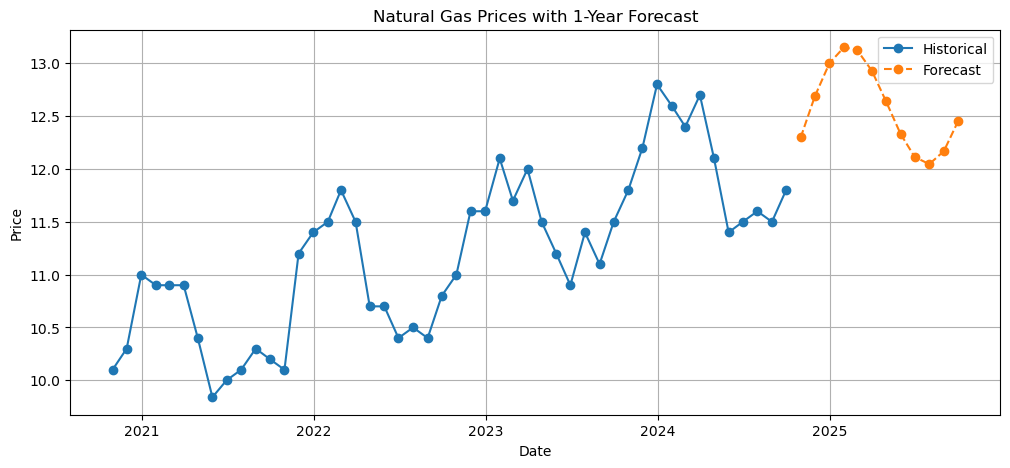

In [10]:
# ---------------------------------------
# 8. Plot historical data and forecast
# ---------------------------------------

plt.figure(figsize=(12,5))

# Historical prices
plt.plot(df["Dates"],
         df["Prices"],
         marker='o',
         label="Historical")

# Forecasted prices
plt.plot(future_dates,
         future_prices,
         marker='o',
         linestyle='--',
         label="Forecast")

plt.title("Natural Gas Prices with 1-Year Forecast")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# ---------------------------------------
# 9. Test the price estimation function
# ---------------------------------------

print("Estimated price on 2023-07-15:",
      estimate_price("2023-07-15"))

print("Estimated price on 2025-05-31:",
      estimate_price("2025-05-31"))

Estimated price on 2023-07-15: 11.141935483870968
Estimated price on 2025-05-31: 12.332265036871537


OBSERVATIONS

- Prices exhibit a clear seasonal pattern, with peaks during colder months and lower values during warmer months.
- There is a general upward trend over parts of the historical period, followed by some stabilization.
- Seasonal demand for heating and storage, weather conditions, supply constraints, and geopolitical factors are common drivers of natural gas price fluctuations.
- Because the data consists of monthly snapshots, interpolation is appropriate for estimating prices between observed dates, while a regression model with seasonal components provides reasonable short-term forecasts.